# Workshop figures (CCAI) — the ensemble spread is under-dispersed, escalating with flow

Frozen ensemble quantities only: the ensemble mean $\hat{\mu}$ and the between-member spread $\hat{\sigma}^2_e$ (sample variance across $M{=}10$ deterministic members, $1/(M{-}1)$ normalization; split unmodified). $\hat{\sigma}^2_e$ **is read as a lower bound on** the epistemic uncertainty a well-specified ensemble should express — never *is* epistemic uncertainty.

**Claim.** The model is skilled (the mean is good), yet $\hat{\sigma}^2_e$ is **pervasively under-dispersed, escalating with flow magnitude**. The spread *does* widen with flow — by $8.5\times$ across the deciles — but the residual widens by $24.6\times$, so the gap opens from $\approx2\times$ to $5.8\times$. It does not widen *enough*; it never fails to widen. Error common to all members (*common-mode*) is invisible to a between-member spread. Aleatoric uncertainty is handled elsewhere [Klotz, Kraft]; there is **no variance head** here — members are deterministic point predictors.

**Shift is the test, not the mechanism** (2026-08-06). The mechanism is flow magnitude and training-support density: the failure is fully present in-distribution, and the top flow decile is where basin-days enter the sparsely-constrained upper tail of training (62% above the basin's train p95, but only 0.69% above its train maximum). The 2021 event windows are a **held-out probe** confirming the same mechanism at greater magnitude — not a separate regime. Separating the two blocks is what forces this reading: the heat dome is *better* calibrated than in-distribution at every decile, and the large pooled OOD number comes from the AR flood alone. See the block-separation diagnostic below.

Figure set: **Overleaf Fig 1** = undersize factor by flow decile; **Overleaf Fig 2** = error after removal on the OOD windows. The event hydrographs below are not used in the workshop paper.

In [1]:
# Frozen ensemble grids + shared plotting style (CCAI, NeurIPS single-column)
import sys, pathlib
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr

# ---- locate project root (dir holding src/config.py), independent of kernel cwd ----
# Re-running this cell self-heals a stale kernel after the source dir moves:
# it finds the current tree and drops any cached `src.*` so the import rebinds.
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "src" / "config.py").exists()), None)
if _root is None:
    raise RuntimeError(f"project root not found from cwd={pathlib.Path.cwd()}; "
                       "launch Jupyter inside the repo (or run this cell from within it).")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
for _m in [m for m in list(sys.modules) if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]
from src.config import OUTPUT_DATA_DIR
print(f"project root: {_root}")

# ============================ SIZING SYSTEM ============================
# Figures render at S x their in-paper size. In LaTeX use:
#     \includegraphics[width=\columnwidth]{fig.pdf}
# S cancels under width=..., so ONLY (aspect ratio) and (font:width ratio)
# reach the page -- both are fixed here. All widths are uniform (=FIG_W*S)
# so the three figures are visually consistent; heights are minimized.
S      = 1.8            # source-render scale ("big"); cancels at width=\columnwidth
FIG_W  = 5.5           # intended in-paper width (NeurIPS/CCAI single-column text width, in)
def figsize(ratio):    # ratio = width:height ; larger ratio => shorter (less vertical space)
    return (FIG_W*S, (FIG_W/ratio)*S)
def off(x, y):  return (x*S, y*S)     # scale offset-point annotation offsets
def sz(area):   return area*S*S       # scale scatter marker AREA (points^2) ~ linear in S

# absolute type/line sizes (pt), all x S so the font:width ratio is invariant
FS = dict(title=10*S, sub=9*S, lab=9*S, tick=8*S, leg=8*S, ann=8*S, emph=10*S)
LW = dict(thin=0.6*S, mu=1.4*S, obs=1.9*S, ref=1.7*S, curve=2.4*S)

# ---- brand-neutral, colorblind-safe (Okabe-Ito), assigned by JOB ----
PALETTE = dict(
    obs    = "#111111",   # observations / realized error (truth)
    mu     = "#8A8A8A",   # ensemble mean mu-hat (recessive reference)
    ens    = "#D55E00",   # between-member spread sigma_e (the signal under test)
    indist = "#0072B2",   # in-distribution / calibrated regime
    ref    = "#555555",   # nominal / best-possible / neutral references
    random = "#AFAFAF",   # no-skill baseline
)
mpl.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 8.5*S,
    "axes.titlesize": FS["title"], "axes.titleweight": "bold", "axes.titlepad": 6*S,
    "axes.labelsize": FS["lab"], "axes.labelpad": 3*S,
    "xtick.labelsize": FS["tick"], "ytick.labelsize": FS["tick"], "legend.fontsize": FS["leg"],
    "axes.linewidth": 0.9*S, "axes.edgecolor": "#444444",
    "axes.grid": True, "grid.color": "#666666", "grid.alpha": 0.28,
    "grid.linestyle": ":", "grid.linewidth": 0.7*S,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "xtick.major.size": 3*S, "ytick.major.size": 3*S,
    "xtick.major.width": 0.8*S, "ytick.major.width": 0.8*S,
    "legend.frameon": False, "mathtext.fontset": "dejavusans",
})
SIG = r"$\hat{\sigma}^2_e$"; MU = r"$\hat{\mu}$"
FIG_OUT = _root/"figures"  # exported PNGs land here, mirroring the Overleaf figures/ dir
FIG_OUT.mkdir(exist_ok=True)

# opaque legend box: panel (b)'s curves and Fig 2's whiskers run behind the legend,
# and rcParams sets frameon=False globally, so text on bare curves was unreadable
LEG = dict(frameon=True, facecolor="white", edgecolor="#CCCCCC", framealpha=.95,
           borderpad=.45, labelspacing=.35, handletextpad=.6)

def panel(ax, letter, title, **kw):
    """Chapter-style bold, left-aligned '(x) Title' panel header."""
    kw.setdefault("fontsize", FS["sub"])
    ax.set_title(f"({letter}) {title}", loc="left", fontweight="bold", **kw)

# ---- frozen quantities (mu-hat, sigma_e^2, split unmodified) ----
R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(R/"y_obs_mm.npy")
try: valid = np.load(R/"valid_mask.npy")
except FileNotFoundError: valid = np.load(R/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz")
mu, sigma_e2 = pred["mu_hat"], pred["sigma_e2"]
sig_e = np.sqrt(sigma_e2)                        # between-member spread
stations = pd.read_csv(R/"q_std.csv")["station_id"].astype(str).to_numpy()
Z = 1.96

# ---- OOD illustration windows (2021 heat dome, AR flood) ----
EVENTS = {"2021 heat dome": ("2021-06-01","2021-07-31"),
          "2021 AR flood":  ("2021-10-20","2021-12-10")}
test = (split=="test")

# Each event gets its own SPATIAL extent -- pooling both over all 269 basins dilutes the
# regional one and flatters it. Heat dome: domain-wide (forcing selection would retain
# 264/269, so restricting is pointless). AR flood: a Lower Mainland / SW-BC event, so
# basins west of -121 deg only -- a generous, purely geographic cut that conditions on
# neither the forcing nor the outcome. See the block-separation cell for the sensitivity.
from src.config import OUTPUT_STATIC_ATTR
_at = pd.read_csv(OUTPUT_STATIC_ATTR, index_col=0); _at.index = _at.index.astype(str)
lon = _at.reindex(stations)["longitude"].values
AR_WEST = (lon < -121) & np.isfinite(lon)                        # 74 basins
HD_DAYS = (dates>=pd.Timestamp("2021-06-01")) & (dates<=pd.Timestamp("2021-07-31"))
AR_DAYS = (dates>=pd.Timestamp("2021-10-20")) & (dates<=pd.Timestamp("2021-12-10"))
ood_date = HD_DAYS | AR_DAYS                                     # dates only (Fig-1 hydrographs)
# AR-window basin-days OUTSIDE the affected region are ordinary autumn conditions, so they
# stay in the in-distribution group; the two groups remain an exhaustive partition of test.
ood_cell = (HD_DAYS[:,None] & np.ones(len(stations), bool)[None,:]) | (AR_DAYS[:,None] & AR_WEST[None,:])
M_ood = (test[:,None] & ood_cell) & valid       # OOD event basin-days (test-only by construction)
M_ind = (test[:,None] & ~ood_cell) & valid      # in-distribution test basin-days
err = np.abs(y-mu); err2 = (y-mu)**2

# within-basin flow-percentile deciles (regime stratification), ranked within the TEST
# period ONLY so train/val flows never inform the binning (test-set-only figures)
pct = pd.DataFrame(np.where(test[:,None] & valid, y, np.nan)).rank(pct=True).to_numpy()
bi = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
tb = (test[:,None] & valid) & np.isfinite(pct)
print(f"style: source {FIG_W*S:.1f}in wide (S={S}); set width=\\columnwidth in LaTeX")
print(f"test basin-days {int(tb.sum()):,} | in-dist {int(M_ind.sum()):,} | OOD {int(M_ood.sum()):,}"
      f"  (heat dome all {len(stations)} basins; AR flood {int(AR_WEST.sum())} basins west of -121)")

project root: /Users/justingallant/src/Research-2026S/EA-LSTM-Streamflow
style: source 9.9in wide (S=1.8); set width=\columnwidth in LaTeX
test basin-days 877,729 | in-dist 857,477 | OOD 20,252  (heat dome all 269 basins; AR flood 74 basins west of -121)


## Figure 1 — Event hydrographs: the ensemble band misses the peak *(illustration)*
Observed runoff vs the ensemble mean $\hat{\mu}$, with the $\pm1.96\,\hat{\sigma}_e$ between-member band, for the two 2021 OOD events. The band is a sliver hugging the mean — it does not reach the observed peaks. These events *illustrate* the population result in Fig. 2; they are not the evidence base.

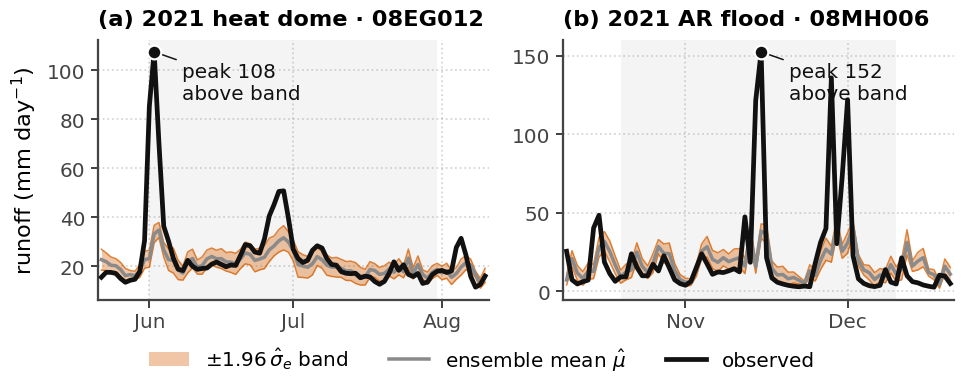

In [2]:
fig, axes = plt.subplots(1, 2, figsize=figsize(2.5))
for k,(ax,(nm,(a,b))) in enumerate(zip(axes, EVENTS.items())):
    a_ts, b_ts = pd.Timestamp(a), pd.Timestamp(b)
    w = (dates >= a_ts-pd.Timedelta(days=10)) & (dates <= b_ts+pd.Timedelta(days=10))
    wi = np.where(w)[0]; core = (dates>=a_ts)&(dates<=b_ts)
    j = int(np.nanargmax(np.nanmax(np.where(core[:,None]&valid, y, np.nan), axis=0)))
    d = dates[wi]; o = y[wi,j]; m = mu[wi,j]; sE = sig_e[wi,j]
    ax.axvspan(a_ts, b_ts, color="#000000", alpha=.045, lw=0, zorder=0)      # event window
    ax.fill_between(d, m-Z*sE, m+Z*sE, color=PALETTE["ens"], alpha=.35, lw=0, zorder=2,
                    label=r"$\pm1.96\,\hat{\sigma}_e$ band")
    ax.plot(d, m+Z*sE, color=PALETTE["ens"], lw=LW["thin"], alpha=.75, zorder=2)
    ax.plot(d, m-Z*sE, color=PALETTE["ens"], lw=LW["thin"], alpha=.75, zorder=2)
    ax.plot(d, m, color=PALETTE["mu"], lw=LW["mu"], zorder=3, label=f"ensemble mean {MU}")
    ax.plot(d, o, color=PALETTE["obs"], lw=LW["obs"], zorder=4, label="observed")
    oc = np.where(core[wi], o, np.nan); kp = int(np.nanargmax(oc))
    ax.plot(d[kp], o[kp], "o", ms=5.5*S, mfc=PALETTE["obs"], mec="white", mew=.9*S, zorder=6)
    ax.annotate(f"peak {o[kp]:.0f}\nabove band", xy=(d[kp], o[kp]),
                xytext=off(11, -4), textcoords="offset points", ha="left", va="top",
                fontsize=FS["ann"], color=PALETTE["obs"],
                arrowprops=dict(arrowstyle="-", lw=LW["thin"], color=PALETTE["obs"]))
    panel(ax, "ab"[k], f"{nm} · {stations[j]}")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.margins(x=.01)
axes[0].set_ylabel(r"runoff (mm day$^{-1}$)")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(.5, -.02), fontsize=FS["leg"])
fig.tight_layout(rect=(0, .07, 1, 1)); plt.show()

**How to read it · station selection.** Each panel shows the single basin with the **largest observed peak** inside that event window, chosen automatically across all 269 basins:

```
core = (dates >= a) & (dates <= b)                                  # the event window
j = nanargmax( nanmax( where(core & valid, y, nan), axis=0 ) )      # basin with the biggest event peak
```

That gives the heat dome → **08EG012** (108 mm day⁻¹) and the AR flood → **08MH006** (152 mm day⁻¹); the plotted window is padded ±10 days so the rise and recession are visible.

- The $\pm1.96\,\hat{\sigma}_e$ band is a **sliver on $\hat{\mu}$** and never reaches the observed peak — the between-member spread does not widen where the model most under-predicts.
- This is **selection on the outcome** (the observed peak), so Fig. 1 is an **illustration, not evidence**, and not representative — the population result in Fig. 2 is the evidence base. Selecting on the *physical event magnitude* (not on model error or on $\hat{\sigma}_e$ itself) keeps it one step removed from circular, but it remains an anecdote backed by the curve, never a proof.

## Figure 1 (Overleaf) — Block composition and undersize factor, by flow regime

**(a)** Where each block's basin-days fall in the flow distribution, and **(b)** how far the ensemble spread falls short in each flow decile. Separate $y$-axes (a density and a dimensionless ratio). Panel (a) is the control panel for (b): the test set is uniform **exactly** by construction — deciles are defined on within-basin test-period ranks — while both event blocks are strongly non-uniform, and any difference between the curves in (b) has to be read knowing that. Percentiles are bounded on $[0,100]$, so the KDE reflects the sample about both ends; without that correction a genuinely uniform block droops at the edges and looks non-uniform.

How many times too narrow the between-member spread is, per within-basin flow decile, for three **mutually exclusive** groups of test basin-days:

- **test set** — the full 2013–2022 test period (269 basins). The two event blocks are **nested inside it**, not disjoint from it: keeping the test set whole is the more intuitive baseline, at the cost that the series no longer partition. Since the events are only 2.3% of test the difference is immaterial (top-decile factor 5.76 for all of test against 5.68 with the events removed), and the strictly event-free split is reported in the block-separation cell below;
- **2021 heat dome** — 1 Jun–31 Jul, domain-wide (269 basins; forcing selection would retain 264/269, so restricting is pointless);
- **2021 AR flood** — 20 Oct–10 Dec, restricted to the **74 basins west of $-121^\circ$**, since it was a Lower Mainland / SW-BC event and scoring it domain-wide dilutes it with ~200 basins in ordinary autumn conditions.

The factor is the standard deviation of the residuals $y-\hat{\mu}$ divided by the RMS between-member spread $\hat{\sigma}_e$, the latter inflated by $\sqrt{(M{+}1)/M}$, $M{=}10$, since $\hat{\sigma}^2_e$ is the $\mathrm{ddof}{=}1$ sample variance. Both terms are standard deviations in mm day$^{-1}$, so the ratio is dimensionless and a calibrated ensemble sits on the dashed line at $1\times$. Because the numerator is an SD, each group's mean residual is removed inside the statistic — the factor carries no bias contribution and is exactly **mean-independent**.

**No inclusion threshold.** Every decile is plotted for every block. The AR block is thin at low flow (39 / 98 / 171 basin-days in deciles 0–30, against 3,843 for that block and 857,477 in-distribution), so the code offers two ways of showing that without dropping anything — `LOWFLOW="thin"` fades points below 200 basin-days, `LOWFLOW="combined"` pools deciles 0–30 into one bin drawn at its full width ($n=308$ for AR). Pooling that range is value-neutral here: the constituent decile means are near-identical, so the between-decile variance contribution is 0.0–5.9% and the pooled factor differs from its parts by $\le0.1$. The same is emphatically *not* true at the top end, where pooling 80–100% would return 4.81 in-distribution against 2.27 and 5.68 for the two deciles, dissolving the very step the figure exists to show.

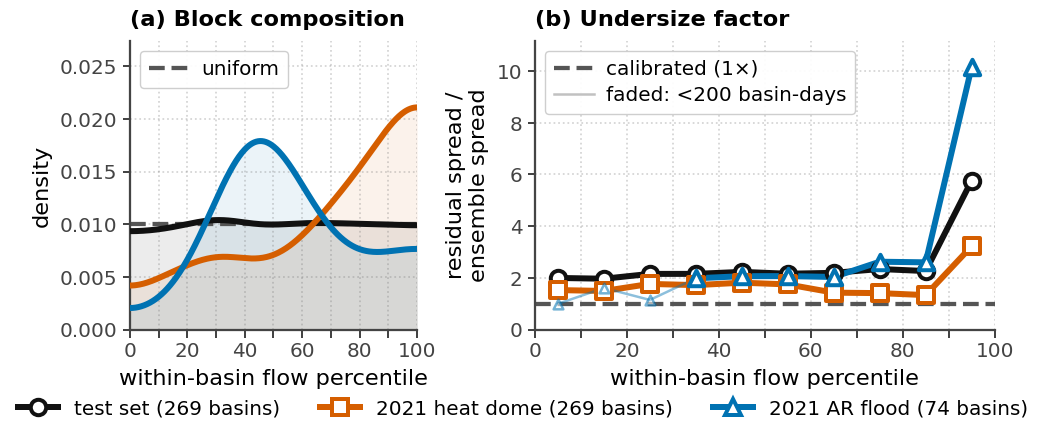

LOWFLOW = 'thin'   (faded / pooled below 200 basin-days)
%days = share of that block's own basin-days falling in the decile (columns sum to 100)
dec |         test set         |      2021 heat dome      |      2021 AR flood       |
    |        n   %days  factor |        n   %days  factor |        n   %days  factor |
  0 |    82,317    9.4%    2.00 |       500    3.0%    1.53 |        39    1.0%    1.00 |
 10 |    88,420   10.1%    1.97 |     1,033    6.3%    1.50 |        98    2.6%    1.61 |
 20 |    90,156   10.3%    2.16 |     1,100    6.7%    1.77 |       171    4.4%    1.15 |
 30 |    96,425   11.0%    2.16 |     1,321    8.1%    1.72 |       743   19.3%    1.99 |
 40 |    84,593    9.6%    2.23 |       897    5.5%    1.82 |     1,016   26.4%    2.07 |
 50 |    85,847    9.8%    2.16 |     1,163    7.1%    1.75 |       632   16.4%    2.07 |
 60 |    86,898    9.9%    2.20 |     1,643   10.0%    1.43 |       342    8.9%    2.04 |
 70 |    87,409   10.0%    2.34 |     2,323   14.2%

In [3]:
# Figure 1 (Overleaf), two panels, separate y-axes:
#   (a) where each block's basin-days sit in the flow distribution (composition)
#   (b) undersize factor by flow decile (the calibration result)
#
# The AR block is thin at low flow (39 / 98 / 171 basin-days in deciles 0-30, against 3,843
# for the block and 857,477 in-distribution). Two ways to be honest about that -- pick one:
LOWFLOW = "thin"          # plot ALL deciles; n only sets line weight, nothing is dropped
# LOWFLOW = "combined"    # pool deciles 0-30 into one wide bin (AR n=308, all points >=200)
#
# No inclusion threshold either way: an n cut-off that drops n=39 while keeping n=98 at full
# weight is an arbitrary constant deciding what the reader sees. Here it only decides how
# things are drawn, so disagreeing with 200 costs the reader nothing.
import json
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
M = json.loads((R/"meta.json").read_text())["n_members"]      # 10; sigma_e2 is ddof=1 per contract
CORR = np.sqrt((M+1)/M)                                       # finite-ensemble spread inflation
cc = np.arange(5,100,10); NTHIN = 200
_XT = list(range(0,101,10))
_XL = [str(t) if t % 20 == 0 else "" for t in _XT]   # ticks every 10, text every 20

# The first series is the WHOLE test set, so the two event blocks are nested inside it
# rather than disjoint from it. That also makes the black curve in (a) exactly uniform by
# construction: deciles are defined on within-basin test-period ranks. The strictly
# event-free comparison lives in the block-separation cell further down.
BLOCKS = [("test set",             tb,                                             "#111111",         "o"),
          ("2021 heat dome",       (test&HD_DAYS)[:,None]&valid,                   PALETTE["ens"],    "s"),
          ("2021 AR flood",        ((test&AR_DAYS)[:,None]&valid)&AR_WEST[None,:], PALETTE["indist"], "^")]
def factor(m):
    if m.sum() < 2: return np.nan
    r=(y-mu)[m]; s=np.sqrt(sigma_e2[m])*CORR
    return r.std()/np.sqrt(np.mean(s**2))

# (b) gets 1.6x the width of (a): the factor curves carry the result and a 4-entry legend,
# while (a) is three smooth curves against a reference line and reads fine narrower.
fig, axs = plt.subplots(1, 2, figsize=figsize(2.3), layout="constrained", width_ratios=[1, 1.6])

# ---------- (a) flow-percentile composition ----------
# Percentiles are bounded on [0,100], and a naive KDE droops at both ends -- which would make a
# genuinely uniform block look non-uniform. Reflecting the sample about 0 and 100 removes that.
a = axs[0]; _rng = np.random.default_rng(0); SUB = 20_000
grid = np.linspace(0, 100, 301)
a.axhline(0.01, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=2, label="uniform")
_dmax = 0
for nm, mask, col, mk in BLOCKS:
    v = pct[mask]*100; v = v[np.isfinite(v)]
    smp = v if len(v) <= SUB else _rng.choice(v, SUB, replace=False)
    dens = 3*gaussian_kde(np.concatenate([smp, -smp, 200-smp]))(grid)   # boundary correction
    a.plot(grid, dens, "-", color=col, lw=LW["curve"], zorder=3)
    a.fill_between(grid, 0, dens, color=col, alpha=.08, lw=0, zorder=1)
    _dmax = max(_dmax, dens.max())
a.set_xlim(0,100); a.set_ylim(0, _dmax*1.30)                 # headroom so no curve is cut
a.set_xticks(_XT); a.set_xticklabels(_XL)
a.set_xlabel("within-basin flow percentile"); a.set_ylabel("density")
a.legend(loc="upper left", **LEG).set_zorder(7)
panel(a, "a", "Block composition")

# ---------- (b) undersize factor ----------
b = axs[1]
b.axhline(1.0, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=2, label="calibrated (1×)")
curves, counts, top, _series = {}, {}, 0, []
for nm, mask, col, mk in BLOCKS:
    v = np.array([factor(mask&(bi==k)) for k in range(10)])
    n = np.array([int((mask&(bi==k)).sum()) for k in range(10)])
    curves[nm], counts[nm] = v, n
    nb_ = int((mask.sum(axis=0)>0).sum())
    if LOWFLOW == "thin":
        g = np.where(np.isfinite(v))[0]
        for a_, b_ in zip(g[:-1], g[1:]):                     # segment weight from the thinner end
            th = min(n[a_], n[b_]) < NTHIN
            b.plot(cc[[a_,b_]], v[[a_,b_]], "-", color=col,
                   lw=(1.0*S if th else LW["curve"]), alpha=(.45 if th else 1), zorder=3)
        for k in g:
            th = n[k] < NTHIN
            b.scatter([cc[k]],[v[k]], s=sz(15 if th else 38), marker=mk, facecolor="white",
                      edgecolor=col, linewidths=(1.0 if th else 1.6)*S,
                      alpha=(.55 if th else 1), zorder=4)
    else:
        low = factor(mask&(bi<3)); rest = np.arange(3,10)
        b.plot([0,30],[low,low], "-", color=col, lw=LW["curve"], zorder=3)   # bar spans the bin
        b.plot([30,cc[3]],[low,v[3]], "-", color=col, lw=LW["curve"], zorder=3)
        b.scatter([15],[low], s=sz(38), marker=mk, facecolor="white", edgecolor=col,
                  linewidths=1.6*S, zorder=4)
        b.plot(cc[rest], v[rest], "-", color=col, lw=LW["curve"], zorder=3)
        b.scatter(cc[rest], v[rest], s=sz(38), marker=mk, facecolor="white", edgecolor=col,
                  linewidths=1.6*S, zorder=4)
    _series.append((f"{nm} ({nb_} basins)", col, mk))     # -> shared legend under the figure
    top = max(top, np.nanmax(v))
b.plot([],[], "-", color="#777777", lw=(1.0*S if LOWFLOW=="thin" else LW["curve"]),
       alpha=(.45 if LOWFLOW=="thin" else 1),
       label=(f"faded: <{NTHIN} basin-days" if LOWFLOW=="thin" else "0–30% pooled (one bin)"))
b.set_ylim(0, top*1.10); b.set_yticks(range(0, int(top)+2, 2))
b.set_xlim(0,100); b.set_xticks(_XT); b.set_xticklabels(_XL)
b.set_xlabel("within-basin flow percentile")
b.set_ylabel("residual spread /\nensemble spread")
b.legend(loc="upper left", **LEG).set_zorder(7)
panel(b, "b", "Undersize factor")
# the three blocks appear in both panels, so their key is shared and sits under the figure;
# each panel's own reference entry stays inside that panel's box
fig.legend(handles=[Line2D([],[], color=c, marker=m, lw=LW["curve"], markerfacecolor="white",
                           markeredgecolor=c, markeredgewidth=1.6*S,
                           markersize=np.sqrt(sz(38)), label=l) for l,c,m in _series],
           loc="outside lower center", ncol=3, frameon=False, fontsize=FS["leg"])
fig.savefig(FIG_OUT/"workshop_fig1_dispersion.png"); plt.show()

print(f"LOWFLOW = {LOWFLOW!r}   (faded / pooled below {NTHIN} basin-days)")
print("%days = share of that block's own basin-days falling in the decile (columns sum to 100)")
print("dec |" + "".join(f"{nm:^26s}|" for nm,_,_,_ in BLOCKS))
print("    |" + "".join(f"{'n':>9s} {'%days':>7s} {'factor':>7s} |" for _ in BLOCKS))
tot = {nm: counts[nm].sum() for nm,_,_,_ in BLOCKS}
for k in range(10):
    row=f"{k*10:3d} |"
    for nm,_,_,_ in BLOCKS:
        row += f" {counts[nm][k]:9,d} {100*counts[nm][k]/tot[nm]:6.1f}% {curves[nm][k]:7.2f} |"
    print(row)
print("    |" + "".join(f" {tot[nm]:9,d} {100.0:6.1f}% {'':7s} |" for nm,_,_,_ in BLOCKS))
print("-"*80)
for nm, mask, _, _ in BLOCKS:
    r=(y-mu)[mask]; s=np.sqrt(sigma_e2[mask])*CORR
    print(f"{nm:22s} n={int(mask.sum()):7,d}  basins={int((mask.sum(axis=0)>0).sum()):3d}  "
          f"overall={r.std()/np.sqrt(np.mean(s**2)):5.2f}  |  pooled 0-30%: "
          f"n={int((mask&(bi<3)).sum()):6,d} factor={factor(mask&(bi<3)):.2f}")
print("\ntop decile: " + "  |  ".join(f"{nm} {curves[nm][9]:.2f}x" for nm,_,_,_ in BLOCKS))

**Discussion.** Across the normal flow range all three blocks sit near $2\times$ too narrow, and the spread widens with flow in every one of them — the ensemble does respond to rising flow, just nowhere near enough. At the top decile the three diverge sharply: the test set as a whole $5.8\times$, heat dome $3.2\times$, AR flood $10.2\times$.

**That ordering is the reason the framing is *shift as test*, not *shift as mechanism*.** The failure is fully present in-distribution, so it needs no distribution shift to appear. The heat dome — the statistically robust event, domain-wide across 269 basins — is *better* calibrated than the test set as a whole, not worse (and than the strictly event-free remainder, $5.68\times$, which the block-separation cell reports); its top-decile residuals are smaller in absolute terms (SD 3.2 vs 5.5 mm day$^{-1}$) despite being a record meteorological event. Only the AR flood degrades. A framing that claimed calibration fails *because* of shift would be carried entirely by the one event that `chapter3.md` (2026-07-13) already flags as spatially blocked and causally ambiguous.

The mechanism the gradient points to is flow magnitude and training-support density: the top decile is where basin-days enter the sparsely-constrained upper tail of the training record (62% above the basin's train p95, though only 0.69% above its train maximum). Since $\hat{\sigma}_e$ is the spread *between* members, it registers only their disagreement; the members share architecture, data and forcing, so error built into that shared setup is **common-mode** — committed by all of them together, leaving agreement high and the spread unable to widen to express it.

$\hat{\sigma}^2_e$ is read as a **lower bound** on the epistemic uncertainty a well-specified ensemble should express. Aleatoric uncertainty is handled elsewhere [Klotz, Kraft]; there is no variance head here.

*Caveats.* This is a second-moment statistic, so it is sensitive to a small number of large misses: within the AR block 12 basin-days carry half the squared error, and removing the top decile moves that block from $7.8\times$ to $2.6\times$. Two independent instruments put the top decile's *bulk* under-dispersion lower than the second moment does — CRPS-optimal inflation $2.5\times$, IQR-based scale $2.1\times$, against $5.8\times$ for the SD — which is itself evidence that the failure is concentrated in the tail rather than a reason to prefer a bulk metric. The leverage-proof complement is the per-basin coverage count in `EXP7` (268 of 269 basins exceed the nominal 5% at their own highest flows). AR per-decile counts are small (39–1,016 basin-days), and its lowest decile is omitted below the 50-basin-day threshold. No interval is placed on any curve: under spatial and temporal autocorrelation an i.i.d. resampling interval would be anti-conservative.

### Figure 1, components — the two terms of the ratio, separately

Figure 1(b) reports a ratio, which hides the fact that **both** of its terms grow steeply with flow. This plots them individually per decile, for each block: the realized residual spread $\mathrm{sd}(y-\hat{\mu})$ (solid) and the ensemble spread $\sqrt{\overline{\hat{\sigma}^2_e}}\sqrt{(M{+}1)/M}$ (dashed), both in mm day$^{-1}$. The vertical gap between a block's two lines *is* its undersize factor, so the widening gap toward the right is the same result read directly.

The claim this settles is that the spread **does** widen with flow — it is not flat, and it never fails to respond. It simply does not widen fast enough. Across the test set's deciles the ensemble spread grows $8.5\times$ while the residual spread grows $24.6\times$.

The $y$-axis is logarithmic here because the two terms span 0.11 to 23.8 mm day$^{-1}$ across blocks and deciles — a factor of ~200, on which a linear axis would compress everything below 2 mm day$^{-1}$ into the axis line. That is a different situation from Fig 1(b), where the plotted quantity spans only 1–10.

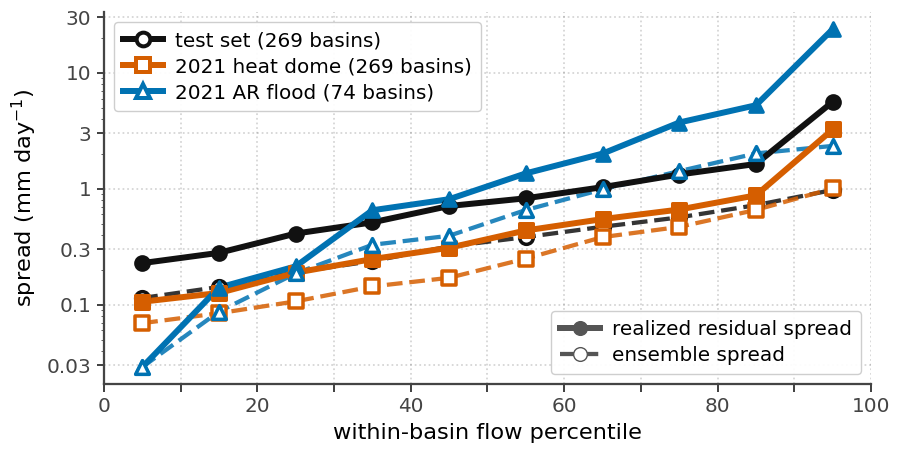

mm/day per decile:  residual spread (solid)  |  ensemble spread (dashed)  |  ratio
dec |           test set           |        2021 heat dome        |        2021 AR flood         |
    |    resid       ens     ratio |    resid       ens     ratio |    resid       ens     ratio |
  0 |     0.228     0.114      2.00 |     0.106     0.069      1.53 |     0.029     0.029      1.00 |
 10 |     0.280     0.142      1.97 |     0.126     0.084      1.50 |     0.140     0.087      1.61 |
 20 |     0.410     0.190      2.16 |     0.189     0.107      1.77 |     0.214     0.186      1.15 |
 30 |     0.512     0.238      2.16 |     0.247     0.144      1.72 |     0.652     0.328      1.99 |
 40 |     0.709     0.318      2.23 |     0.309     0.170      1.82 |     0.811     0.392      2.07 |
 50 |     0.827     0.382      2.16 |     0.436     0.249      1.75 |     1.356     0.655      2.07 |
 60 |     1.031     0.469      2.20 |     0.547     0.382      1.43 |     2.008     0.986      2.04 |
 70 |

In [4]:
# Figure 1 components: numerator and denominator of the undersize factor, plotted separately.
# The ensemble spread carries the same sqrt((M+1)/M) correction as the ratio, so the vertical
# gap between a block's solid and dashed line is exactly that block's factor.
fig, ax = plt.subplots(figsize=figsize(2.05))
comp = {}
for nm, mask, col, mk_ in BLOCKS:
    sd = np.array([ (y-mu)[mask&(bi==k)].std() if (mask&(bi==k)).sum()>=2 else np.nan
                    for k in range(10)])
    sp = np.array([ np.sqrt(np.mean(sigma_e2[mask&(bi==k)]))*CORR if (mask&(bi==k)).sum()>=2 else np.nan
                    for k in range(10)])
    comp[nm] = (sd, sp)
    ax.plot(cc, sd, "-",  color=col, lw=LW["curve"], zorder=4)
    ax.scatter(cc, sd, s=sz(30), marker=mk_, facecolor=col, edgecolor=col, linewidths=1.2*S, zorder=5)
    ax.plot(cc, sp, "--", color=col, lw=LW["ref"], alpha=.85, zorder=3)
    ax.scatter(cc, sp, s=sz(30), marker=mk_, facecolor="white", edgecolor=col, linewidths=1.4*S, zorder=5)
ax.set_yscale("log")
ax.set_xlim(0,100); ax.set_xticks(_XT); ax.set_xticklabels(_XL)
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel(r"spread (mm day$^{-1}$)")
ax.set_yticks([0.03,0.1,0.3,1,3,10,30])
ax.set_yticklabels(["0.03","0.1","0.3","1","3","10","30"])
# both keys sit inside: on a single-panel figure an outside legend collides with the xlabel
_l1 = ax.legend(handles=[Line2D([],[], color="#555555", lw=LW["curve"], marker="o",
                                markerfacecolor="#555555", markeredgecolor="#555555",
                                markersize=np.sqrt(sz(30)), label="realized residual spread"),
                         Line2D([],[], color="#555555", lw=LW["ref"], ls="--", marker="o",
                                markerfacecolor="white", markeredgecolor="#555555",
                                markersize=np.sqrt(sz(30)), label="ensemble spread")],
                loc="lower right", **LEG)
_l1.set_zorder(7); ax.add_artist(_l1)
ax.legend(handles=[Line2D([],[], color=c, marker=m, lw=LW["curve"], markerfacecolor="white",
                          markeredgecolor=c, markeredgewidth=1.6*S,
                          markersize=np.sqrt(sz(30)), label=l) for l,c,m in _series],
          loc="upper left", **LEG).set_zorder(7)
fig.savefig(FIG_OUT/"workshop_fig1_components.png"); plt.show()

print("mm/day per decile:  residual spread (solid)  |  ensemble spread (dashed)  |  ratio")
print("dec |" + "".join(f"{nm:^30s}|" for nm,_,_,_ in BLOCKS))
print("    |" + "".join(f"{'resid':>9s} {'ens':>9s} {'ratio':>9s} |" for _ in BLOCKS))
for k in range(10):
    row=f"{k*10:3d} |"
    for nm,_,_,_ in BLOCKS:
        sd,sp = comp[nm]
        row += f" {sd[k]:9.3f} {sp[k]:9.3f} {sd[k]/sp[k]:9.2f} |"
    print(row)
print("-"*100)
for nm,_,_,_ in BLOCKS:
    sd,sp = comp[nm]
    print(f"{nm:18s} growth decile 0->90:  residual x{sd[9]/sd[0]:5.1f}   ensemble x{sp[9]/sp[0]:5.1f}"
          f"   -> the gap widens x{(sd[9]/sp[9])/(sd[0]/sp[0]):.1f}")

### Supplement (not the CCAI figure) — standardized-residual distribution

Retained for the HESS distributional supplement and for the per-decile exceedance numbers it prints. **Not exported and not used as the CCAI figure:** its basis $z=(y-\hat{\mu}-\overline{r}_k)/\hat{\sigma}_e$ subtracts each decile's *pooled* mean residual in mm day$^{-1}$ and then divides by a *per-cell* $\hat{\sigma}_e$ that varies by orders of magnitude. That ordering injects an offset of $|\overline{r}_k|/\hat{\sigma}_e$ per cell — which ranges from 0.30 to 2.75 across deciles, driving the apparent 80–90% dip — and at the top decile it inverts the asymmetry, halving the genuine positive tail ($q_{97.5}$ from $+19.2$ to $+10.6$) while manufacturing a $-42.7$ negative one. The spread–skill ratio above avoids all of this by never removing a mean.

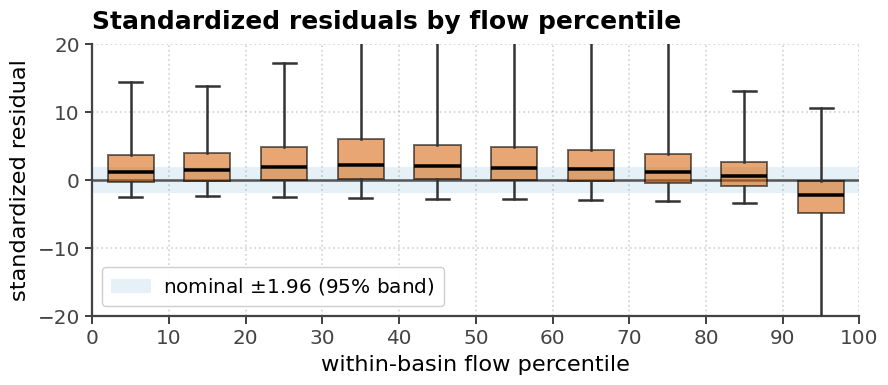

decile        n     q2.5   q97.5   % |z|>1.96
  0-10    82,317    -2.50   14.35       44.8
 10-20    88,420    -2.35   13.79       47.7
 20-30    90,156    -2.47   17.18       53.1
 30-40    96,425    -2.65   20.62       57.8
 40-50    84,593    -2.83   23.46       56.0
 50-60    85,847    -2.81   24.75       53.8
 60-70    86,898    -2.99   23.77       51.6
 70-80    87,409    -3.12   21.15       48.3
 80-90    87,734    -3.36   13.08       40.6
 90-100   87,930   -42.66   10.61       64.9
pooled: 52.0% of |z| exceeds 1.96 (nominal 5%)
y-axis clipped at +/-20; whisker extremes span -42.7 to 24.8


In [5]:
# SUPPLEMENT (not exported, not the CCAI figure): standardized-residual distribution by
# flow decile. Basis is confounded -- see the note above -- kept for the HESS distributional
# supplement and for the per-decile exceedance numbers it prints.
cc=np.arange(5,100,10); zlist=[]
for k in range(10):
    m=(bi==k)&tb; rk=(y-mu)[m]; sk=sig_e[m]; ok=sk>1e-6
    zlist.append((rk-rk.mean())[ok]/sk[ok])      # z = (y-mu)/sigma_e, per-decile mean removed
YL=20                                            # spans every upper whisker; top decile's lower one (-42.7) is cut
fig,ax=plt.subplots(figsize=figsize(2.8))
ax.axhspan(-Z,Z,color=PALETTE["indist"],alpha=.10,lw=0,zorder=0,label=r"nominal $\pm1.96$ (95% band)")
ax.axhline(0,color=PALETTE["ref"],lw=1.0*S,zorder=1)
bp=ax.boxplot(zlist,positions=cc,widths=6,whis=[2.5,97.5],showfliers=False,patch_artist=True,zorder=3)
for box in bp["boxes"]: box.set(facecolor=PALETTE["ens"],alpha=.55,edgecolor="black",linewidth=.8*S)
for med in bp["medians"]: med.set(color="black",linewidth=1.4*S)
for el in bp["whiskers"]+bp["caps"]: el.set(color="#333333",linewidth=1.0*S)
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel("standardized residual")
ax.set_title("Standardized residuals by flow percentile",loc="left")
ax.set_xlim(0,100); ax.set_ylim(-YL,YL)
# both calls are needed: boxplot leaves a FixedFormatter that mislabels the new tick positions
ax.set_xticks(range(0,101,10)); ax.set_xticklabels(range(0,101,10))
ax.legend(loc="lower left",**LEG).set_zorder(7)
plt.show()

# numbers behind the boxes (the y-axis is clipped, so read the whisker positions here)
q=np.array([[np.percentile(z,2.5),np.percentile(z,97.5)] for z in zlist])
print("decile        n     q2.5   q97.5   % |z|>1.96")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<3d} {zlist[k].size:8,d} {q[k,0]:8.2f} {q[k,1]:7.2f} {100*np.mean(np.abs(zlist[k])>Z):10.1f}")
zall=np.concatenate(zlist)
print(f"pooled: {100*np.mean(np.abs(zall)>Z):.1f}% of |z| exceeds 1.96 (nominal 5%)")
print(f"y-axis clipped at +/-{YL}; whisker extremes span {q.min():.1f} to {q.max():.1f}")

## Figure 2 (Overleaf) — Error after removal, one panel per block

Basin-days are discarded largest-first under three removal rules and the RMSE of whatever remains is plotted against the fraction discarded. Discarding **by ensemble spread** is the rule under test; discarding **by actual error** (the oracle) removes the genuinely worst predictions first and is the best any rule could do, computable only after the fact; discarding **at random** is what a rule carrying no information achieves (mean of 10 permutations). **AUSE** places the spread curve between those bounds: $0$ means discarding by spread is as effective as discarding by actual error, $1$ means no better than random.

**The two 2021 events are shown separately, not pooled.** They differ 4.8× in RMSE (1.69 vs 8.06 mm day$^{-1}$), and AUSE is a scale-based metric, so pooling them lets the removal rule take out the entire high-RMSE block first — ordering skill that is not within-block discrimination. Pooled AUSE is 0.049, *lower than either event on its own* (0.082 and 0.086), which is the same composition artifact that appears when flow deciles are pooled. Panels have **independent $y$-axes** for the same reason; the comparison runs through the AUSE values, not by eye across panels.

This asks only whether $\hat{\sigma}^2_e$ carries information about *which* predictions are poor — it is not a proposal to use the spread that way. No interval is reported: see the discussion.

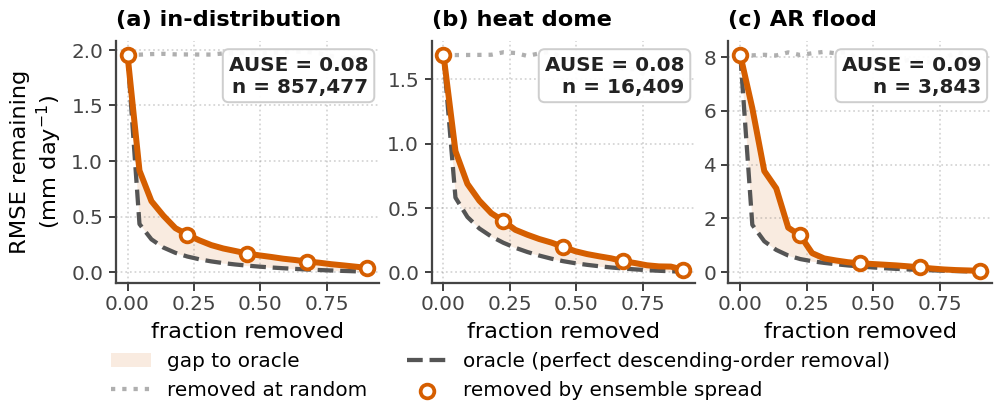

separated blocks (y-axes are independent; RMSE at f=0 differs 4.8x across them)
block                      n  RMSE(f=0)    AUSE  rho(sigma_e^2,|err|)
in-distribution      857,477      1.954   0.079                 0.771
heat dome             16,409      1.690   0.082                 0.826
AR flood               3,843      8.060   0.086                 0.846
[events pooled]       20,252              0.049                 0.831   <- pooling artifact, not reported

AUSE is scale-based, so pooling two blocks of very different RMSE creates across-block
ordering skill that is not within-block discrimination. rho is rank-based and is not
affected the same way (0.826 and 0.846 separately, 0.831 pooled).


In [6]:
# Figure 2 (Overleaf): error after removal (sparsification), one panel per block.
# The two 2021 events are shown SEPARATELY, not pooled: they differ 4.8x in RMSE (1.69 vs
# 8.06 mm/day), and pooling lets the removal rule take out the whole high-RMSE block first,
# which flatters the pooled AUSE (0.049) below either event on its own (0.082, 0.086).
# Diagnostic only -- asks whether sigma_e^2 carries information about WHICH predictions are
# poor. No CI: the claim is that the spread orders error, not that two orderings differ, and
# under autocorrelation an i.i.d. interval here would be anti-conservative for no benefit.
def sparsify(se, e2, nf=21, seed=0):
    n=len(e2); fr=np.linspace(0,0.9,nf); op=np.argsort(-se); oo=np.argsort(-e2); rng=np.random.default_rng(seed)
    curve=lambda order: np.array([np.sqrt(np.mean(e2[order[int(f*n):]])) for f in fr])
    cp,co_=curve(op),curve(oo); cr=np.mean([curve(rng.permutation(n)) for _ in range(10)],axis=0)
    num=np.trapezoid(cp-co_,fr); den=np.trapezoid(cr-co_,fr)
    return fr,cp,co_,cr,(num/den if den>0 else np.nan)

PANELS = [("in-distribution", M_ind),
          ("heat dome",       (test&HD_DAYS)[:,None]&valid),
          ("AR flood",        ((test&AR_DAYS)[:,None]&valid)&AR_WEST[None,:])]
fig, axs = plt.subplots(1, 3, figsize=figsize(2.4), layout="constrained")
res = {}
for k,(ax,(nm,m)) in enumerate(zip(axs, PANELS)):
    fr,cp,co_,cr,an = sparsify(sigma_e2[m], err2[m]); res[nm] = (an, int(m.sum()), cp[0])
    ax.fill_between(fr,co_,cp,color=PALETTE["ens"],alpha=.12,lw=0,zorder=1,label="gap to oracle")
    ax.plot(fr,cr,":",color=PALETTE["random"],lw=LW["ref"],zorder=2,label="removed at random")
    ax.plot(fr,co_,"--",color=PALETTE["ref"],lw=LW["ref"],zorder=3,
            label="oracle (perfect descending-order removal)")
    ax.plot(fr,cp,"-",color=PALETTE["ens"],lw=LW["curve"],zorder=4)
    ax.scatter(fr[::5],cp[::5],s=sz(30),facecolor="white",edgecolor=PALETTE["ens"],
               linewidths=1.5*S,zorder=5,label="removed by ensemble spread")
    panel(ax,"abc"[k],nm)                      # n goes in the box; 3 narrow panels cannot hold it
    ax.set_xlabel("fraction removed")
    ax.annotate(f"AUSE = {an:.2f}\nn = {int(m.sum()):,}", xy=(.96,.94), xycoords="axes fraction",
                ha="right", va="top", fontsize=FS["ann"], fontweight="bold", color="#222222", zorder=7,
                bbox=dict(boxstyle="round,pad=.3", fc="white", ec="#CCCCCC", lw=.8*S, alpha=.95))
axs[0].set_ylabel("RMSE remaining\n"r"(mm day$^{-1}$)")
h,l = axs[0].get_legend_handles_labels()
fig.legend(h, l, loc="outside lower center", ncol=2, frameon=False, fontsize=FS["leg"])
fig.savefig(FIG_OUT/"workshop_fig2_shift.png"); plt.show()

print("separated blocks (y-axes are independent; RMSE at f=0 differs 4.8x across them)")
print(f"{'block':18s} {'n':>9s} {'RMSE(f=0)':>10s} {'AUSE':>7s} {'rho(sigma_e^2,|err|)':>21s}")
for nm,m in PANELS:
    an,n,r0 = res[nm]
    print(f"{nm:18s} {n:9,d} {r0:10.3f} {an:7.3f} {spearmanr(sigma_e2[m],err[m]).statistic:21.3f}")
_po = (test[:,None]&ood_cell)&valid
_,_,_,_,an_p = sparsify(sigma_e2[_po], err2[_po])
print(f"{'[events pooled]':18s} {int(_po.sum()):9,d} {'':10s} {an_p:7.3f} "
      f"{spearmanr(sigma_e2[_po],err[_po]).statistic:21.3f}   <- pooling artifact, not reported")
print("\nAUSE is scale-based, so pooling two blocks of very different RMSE creates across-block")
print("ordering skill that is not within-block discrimination. rho is rank-based and is not")
print("affected the same way (0.826 and 0.846 separately, 0.831 pooled).")

**Discussion.** Fig. 1 establishes that the spread is too narrow — $\approx2.2\times$ across normal flows, $5.8\times$ at the extreme. This figure asks a separate question: does $\hat{\sigma}^2_e$ still indicate *where* the error is large? That distinguishes **confidently wrong** (orders error correctly, magnitude far too small) from **decoupled** (spread unrelated to error). The two properties are orthogonal — a signal can rank error perfectly and still be uniformly too small, and so be overconfident everywhere.

**The ordering holds, and it is essentially unchanged across blocks.** AUSE is 0.079 in-distribution, 0.082 at the heat dome, 0.086 at the AR flood — the spread stays far closer to the oracle than to random everywhere, and the two events are marginally *worse* than in-distribution rather than better. The rank correlation between $\hat{\sigma}^2_e$ and $|y-\hat{\mu}|$ agrees and is slightly stronger at both events: $0.771$ in-distribution, $0.826$ at the heat dome, $0.846$ at the AR flood. What fails under shift is the **magnitude, not the ordering** — which is what makes the Fig. 1 result *confidently wrong* rather than uninformative, and forecloses reading the spread as noise at the events.

*Correction from an earlier pooled version.* Reporting the two events as one block gave AUSE $=0.049$ and supported a claim that ordering skill *improves* under shift. That was a pooling artifact: with a 4.8× RMSE difference between the blocks, the removal rule can discard the high-RMSE block wholesale, which is across-block ordering rather than discrimination within either event. Separated, the honest claim is that ordering skill is **unchanged**, which the argument needs and which is harder to attack. $\rho$ was not affected in the same way — it is rank-based, so pooling blends the two values (0.831) rather than inflating past both.

The claim is **diagnostic**. Nothing here recommends $\hat{\sigma}_e$ as an operational triage signal; establishing that would require a decision-analytic evaluation this paper does not attempt.

*Caveats.* **No interval is placed on AUSE or on the rank correlations, deliberately.** Basin-days are pooled within block, so under spatial and temporal autocorrelation the effective sample size is far below the count, and an i.i.d. resampling interval would be anti-conservative. The claim is that the spread orders error at all, not that two orderings differ by a stated amount. The oracle curve is a post-hoc bound, not an attainable baseline. The AR panel rests on 3,843 basin-days across 74 basins west of $-121^\circ$; the flow-composition control below is computed on the *pooled* event block and so inherits the artifact described above — the per-event values here are the cleaner reference.

### Flow-composition control for Figure 2 (reproduces the caveat numbers)

Both $\hat{\sigma}_e$ and $|y-\hat{\mu}|$ grow with flow magnitude, so pooling deciles gives the ordering an across-regime signal that is not discrimination *within* a regime. Recomputing AUSE separately inside each within-basin flow decile of the OOD cells holds that composition fixed. Reported, not plotted — the within-stratum reference curves differ from the pooled ones, so the two cannot share a panel honestly.

In [7]:
# Flow-composition control: AUSE within each flow decile of the OOD cells.
# Reuses sparsify() from the Figure 2 cell; seeded, so the numbers are reproducible.
per=np.full(10,np.nan); ns=np.zeros(10,int)
for k in range(10):
    m=M_ood&(bi==k); ns[k]=int(m.sum())
    if ns[k]>=200: per[k]=sparsify(sigma_e2[m], err2[m])[4]
pooled=sparsify(sigma_e2[M_ood], err2[M_ood])[4]
print("decile      n    AUSE")
for k in range(10): print(f"{k*10:3d}-{k*10+10:<3d} {ns[k]:7,d} {per[k]:7.3f}")
print(f"\npooled (unstratified)          {pooled:.3f}")
print(f"within-decile, n-weighted      {np.average(per,weights=ns):.3f}   <- quoted in the paper")
print(f"within-decile, unweighted      {np.nanmean(per):.3f}")
print(f"top three deciles (70-100%)    {per[7:].min():.3f}-{per[7:].max():.3f}   <- quoted in the paper")
print(f"random ordering would give     1.000")

# Table as Appendix

decile      n    AUSE
  0-10      539   0.090
 10-20    1,131   0.091
 20-30    1,271   0.079
 30-40    2,064   0.062
 40-50    1,913   0.093
 50-60    1,795   0.061
 60-70    1,985   0.078
 70-80    2,565   0.089
 80-90    2,897   0.132
 90-100   4,092   0.149

pooled (unstratified)          0.049
within-decile, n-weighted      0.101   <- quoted in the paper
within-decile, unweighted      0.092
top three deciles (70-100%)    0.089-0.149   <- quoted in the paper
random ordering would give     1.000


### Block separation — heat dome vs AR flood (why shift is the test, not the mechanism)

The pooled "OOD" grouping mixes two physically distinct events with **different spatial extents**, and pooling them is what produced the misleading combined number.

- **Heat dome — domain-wide.** Forcing selection (Jun–Jul Tmax $z>1.5$ vs other years) retains **264 of 269** basins, matching the selection-robustness noted in `chapter3.md` (2026-07-13). Restricting changes nothing (factor 2.83 either way), so the block is left unrestricted.
- **AR flood — regional.** November 2021 was a Lower Mainland / SW-BC event; scoring it over all 269 basins dilutes it with ~200 basins in ordinary autumn conditions and *flatters* it. The block is restricted to basins **west of $-121^\circ$ (74 basins)** — a generous coastal cut, purely geographic, so it conditions on neither the forcing nor the outcome.

**Why not the forcing selector from EXP5 cell 13d here.** Applying Nov-precip $z>1.5$ domain-wide selects 88 basins, but only 3 lie west of $-123^\circ$ and the set is dominated by interior Columbia/Kootenay and Athabasca basins — median longitude $-116.5^\circ$, *east* of the domain median. Standardizing precipitation against each basin's own November climatology favours dry interior basins where any rain is anomalous and penalises coastal basins that are wet and variable every November. Within the coastal block the median $z$ is only 0.50. That selector remains valid for its original purpose (avoiding outcome-conditioning in the shrinkage slope) but is **not** an event-membership filter.

**Caveat on the definition.** A longitude threshold is a crude proxy for the SW-BC corridor. `chapter3.md` §5 (2D) refers to a citation-grounded corridor of ~31 basins (22 precip-confirmed); if that list exists it should supersede this cut, and the definition belongs in the methods log before it is used in the paper. The sensitivity ladder printed below exists so the choice is auditable — every tighter definition makes the AR block *worse*, so the generous cut is the conservative one.

Two results follow, and together they are why the framing moved from *shift as mechanism* to *shift as test*: at **matched flow percentile** the heat dome is *better* calibrated than in-distribution (top decile 3.23 vs 5.66) while the AR flood is worse (10.16). One event degrades, one does not. Note also `chapter3.md` §7: the AR flood's most credible cause is orographic precipitation under-capture, i.e. a **forcing** error shared by every member — still common-mode, but originating upstream of the model, which is a weaker basis for a claim about the model's own epistemic humility.

This does not contradict the heat-dome mean regression recorded in `chapter3.md` ($\hat{\mu}/\mathrm{obs}\approx0.81$): that is a statement about **bias**, which the residual SD in this factor removes by construction.

In [8]:
# Block separation: per-decile undersize factor, in-distribution vs each 2021 event.
# Heat dome = domain-wide (forcing-selection retains 264/269, so no restriction).
# AR flood  = regional, restricted to basins west of -121 deg (74 basins); see note above.
from src.config import PROCESSED_DATA_DIR
# AR_WEST, HD_DAYS, AR_DAYS and lon all come from the load cell -- one definition, reused.
HD, AR = HD_DAYS, AR_DAYS
B = {"in-distribution": M_ind,
     "heat dome (269)": (test&HD)[:,None]&valid,
     "AR flood (74 W)": ((test&AR)[:,None]&valid) & AR_WEST[None,:]}
def fac(m, minn=30):
    if m.sum()<minn: return (int(m.sum()), np.nan, np.nan)
    r=(y-mu)[m]; s=np.sqrt(sigma_e2[m])*CORR
    return (int(m.sum()), r.std(), r.std()/np.sqrt(np.mean(s**2)))

print("per-decile undersize factor by block      (n / resid SD / factor)")
print("dec |   in-distribution    |   heat dome (all 269) |   AR flood (74 west)")
for k in range(10):
    row=f"{k*10:3d} |"
    for nm,m in B.items():
        n,sd,f=fac(m&(bi==k))
        row += f" {n:7,d} {sd:6.2f} {f:6.2f} |" if np.isfinite(f) else f" {n:7,d}   (n<30)   |"
    print(row)
print("-"*70)
for nm,m in B.items():
    n,sd,f=fac(m); print(f"{nm:16s} n={n:7,d}  basins={int((m.sum(axis=0)>0).sum()):3d}"
                         f"  resid SD={sd:6.3f}  factor={f:5.2f}")
print("\nmatched-flow comparison (top decile): in-dist "
      f"{fac(B['in-distribution']&(bi==9))[2]:.2f}  |  heat dome {fac(B['heat dome (269)']&(bi==9))[2]:.2f}"
      f"  |  AR flood {fac(B['AR flood (74 W)']&(bi==9))[2]:.2f}")
print("-> heat dome is BETTER calibrated than in-distribution; only the AR flood is worse.")

# sensitivity ladder for the AR definition: every tighter cut makes it worse, so the
# generous geographic cut is the conservative choice.
_pf = PROCESSED_DATA_DIR/"climate"/"daily_precipitation.csv"
print("\nAR definition sensitivity (top-decile factor):")
lad = [("all 269 basins (diluted)", np.isfinite(lon)), ("west of -120", lon<-120),
       ("west of -121  [canonical]", lon<-121), ("west of -122", lon<-122), ("west of -123", lon<-123)]
if _pf.exists():
    _p = pd.read_csv(_pf, index_col=0, parse_dates=True).reindex(index=dates, columns=stations)
    _s = (dates.month==11); _w = _p[_s].groupby(dates.year[_s]).max(); _o = _w.drop(index=2021)
    zP = ((_w.loc[2021]-_o.mean())/_o.std()).values
    lad += [("west -121 & Nov P z>1.0", (lon<-121)&(zP>1.0)),
            ("west -121 & Nov P z>1.5", (lon<-121)&(zP>1.5))]
for nm,g in lad:
    g=g&np.isfinite(lon); m=((test&AR)[:,None]&valid)&g[None,:]
    n,_,f=fac(m); nt,_,ft=fac(m&(bi==9))
    print(f"  {nm:26s} basins={int(g.sum()):3d}  n={n:6,d}  overall="
          + (f"{f:5.2f}" if np.isfinite(f) else "    -")
          + f"  top decile=" + (f"{ft:6.2f} (n={nt:,})" if np.isfinite(ft) else "   (n<30)"))

per-decile undersize factor by block      (n / resid SD / factor)
dec |   in-distribution    |   heat dome (all 269) |   AR flood (74 west)
  0 |  81,778   0.23   2.00 |     500   0.11   1.53 |      39   0.03   1.00 |
 10 |  87,289   0.28   1.97 |   1,033   0.13   1.50 |      98   0.14   1.61 |
 20 |  88,885   0.41   2.16 |   1,100   0.19   1.77 |     171   0.21   1.15 |
 30 |  94,361   0.51   2.16 |   1,321   0.25   1.72 |     743   0.65   1.99 |
 40 |  82,680   0.71   2.24 |     897   0.31   1.82 |   1,016   0.81   2.07 |
 50 |  84,052   0.82   2.16 |   1,163   0.44   1.75 |     632   1.36   2.07 |
 60 |  84,913   1.03   2.20 |   1,643   0.55   1.43 |     342   2.01   2.04 |
 70 |  84,844   1.32   2.35 |   2,323   0.66   1.41 |     242   3.72   2.63 |
 80 |  84,837   1.63   2.27 |   2,686   0.88   1.34 |     211   5.25   2.60 |
 90 |  83,838   5.47   5.68 |   3,743   3.24   3.23 |     349  23.77  10.16 |
----------------------------------------------------------------------
in-distri

### Alternate Figure 2 — regime comparison (in-distribution vs 2021 events)

Same sparsification diagnostic as Figure 2, run separately on the two disjoint halves of the test split: cells outside the 2021 event windows ($n=850{,}664$) and cells inside them ($n=27{,}065$). The question is whether the spread's ability to *order* error degrades under shift.

Panels carry **independent $y$-scales** — the event windows start from a much larger RMSE (3.46 vs 1.95 mm day$^{-1}$), so a shared axis would flatten the in-distribution panel. The comparison is therefore made through the two AUSE values, not by eye across panels. Exported separately as `workshop_fig2_regimes.png`; the single-panel Figure 2 remains the primary.

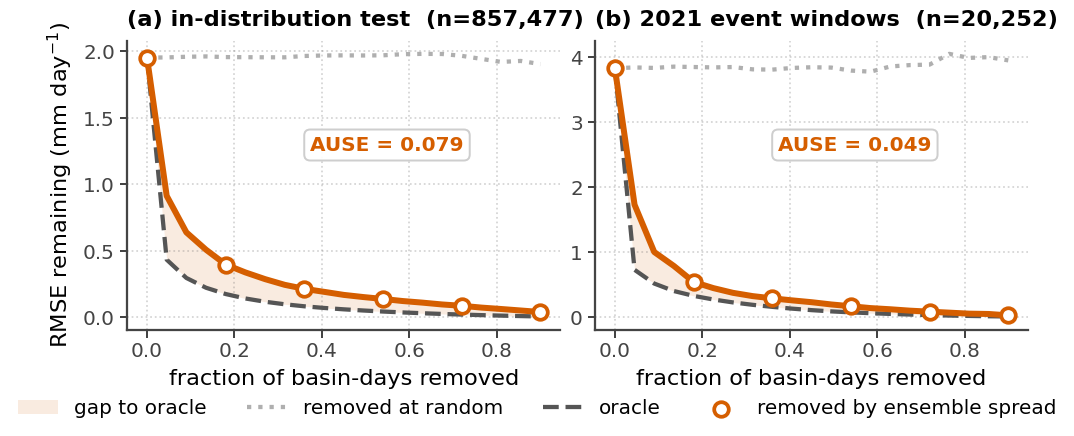

in-distribution  n=857,477  RMSE(f=0)=1.954  AUSE=0.079
2021 windows     n=20,252  RMSE(f=0)=3.827  AUSE=0.049
ordering skill does not degrade under shift (AUSE is lower at the events);
random ordering would give 1.000 in both regimes.


In [9]:
# Alternate Figure 2: sparsification run separately in-distribution vs OOD windows.
# Reuses sparsify() from the Figure 2 cell. AUSE is computed, never hardcoded, so this
# figure and the primary Figure 2 cannot drift apart on the shared OOD number.
fr_i,cp_i,co_i,cr_i,an_i = sparsify(sigma_e2[M_ind], err2[M_ind])
fr_o,cp_o,co_o,cr_o,an_o = sparsify(sigma_e2[M_ood], err2[M_ood])

fig, axs = plt.subplots(1, 2, figsize=figsize(2.3), layout="constrained")
panels = [(cp_i,co_i,cr_i,an_i,"in-distribution test",int(M_ind.sum())),
          (cp_o,co_o,cr_o,an_o,"2021 event windows",  int(M_ood.sum()))]
for k,(a,(cp,co,cr,au,ttl,nn)) in enumerate(zip(axs,panels)):
    a.fill_between(fr_i,co,cp,color=PALETTE["ens"],alpha=.12,lw=0,zorder=1,label="gap to oracle")
    a.plot(fr_i,cr,":",color=PALETTE["random"],lw=LW["ref"],zorder=2,label="removed at random")
    a.plot(fr_i,co,"--",color=PALETTE["ref"],lw=LW["ref"],zorder=3,label="oracle")
    a.plot(fr_i,cp,"-",color=PALETTE["ens"],lw=LW["curve"],zorder=4)
    a.scatter(fr_i[::4],cp[::4],s=sz(34),facecolor="white",edgecolor=PALETTE["ens"],
              linewidths=1.5*S,zorder=5,label="removed by ensemble spread")
    panel(a,"ab"[k],f"{ttl}  (n={nn:,})")
    a.set_xlabel("fraction of basin-days removed")
    a.annotate(f"AUSE = {au:.3f}",xy=(.60,.62),xycoords="axes fraction",ha="center",
               fontsize=FS["ann"],fontweight="bold",color=PALETTE["ens"],zorder=6,
               bbox=dict(boxstyle="round,pad=.3",fc="white",ec="#CCCCCC",lw=.8*S,alpha=.95))
axs[0].set_ylabel(r"RMSE remaining (mm day$^{-1}$)")
h,l = axs[0].get_legend_handles_labels()
fig.legend(h,l,loc="outside lower center",ncol=4,fontsize=FS["leg"],frameon=False)
fig.savefig(FIG_OUT/"workshop_fig2_regimes.png"); plt.show()

print(f"in-distribution  n={int(M_ind.sum()):,}  RMSE(f=0)={cp_i[0]:.3f}  AUSE={an_i:.3f}")
print(f"2021 windows     n={int(M_ood.sum()):,}  RMSE(f=0)={cp_o[0]:.3f}  AUSE={an_o:.3f}")
print("ordering skill does not degrade under shift (AUSE is lower at the events);")
print("random ordering would give 1.000 in both regimes.")

### Reserve check — CRPS (not a paper figure)

Held in reserve in case a probabilistic-ML reviewer asks for a proper scoring rule rather than AUSE and the spread–skill ratio. Treats the ensemble as $\mathcal{N}(\hat{\mu},\,(c\,\hat{\sigma}_e)^2)$ and asks which spread inflation $c$ *minimises* CRPS in each flow decile — an independent estimate of how far the spread is from the scale a proper score would prefer. A calibrated spread would put $c^\star=1$.

CRPS uses the closed form $\mathrm{CRPS}(\mathcal{N}(\mu,\sigma),y)=\sigma\left[z(2\Phi(z)-1)+2\phi(z)-\pi^{-1/2}\right]$, $z=(y-\hat{\mu})/\sigma$, verified against numerical integration of $\int(F-\mathbb{1}\{x\ge y\})^2dx$ to $10^{-9}$ at $z=0$. $\hat{\sigma}_e$ carries the same $\sqrt{(M{+}1)/M}$ correction as Figure 1, so $c$ is measured on the same scale as that figure's undersize factor. **This is the Gaussian-family CRPS, not the empirical ensemble CRPS** — the latter needs the 10 member series, which are not in the `results_MVE` contract (only aggregate moments), so computing it would mean re-deriving the index alignment.

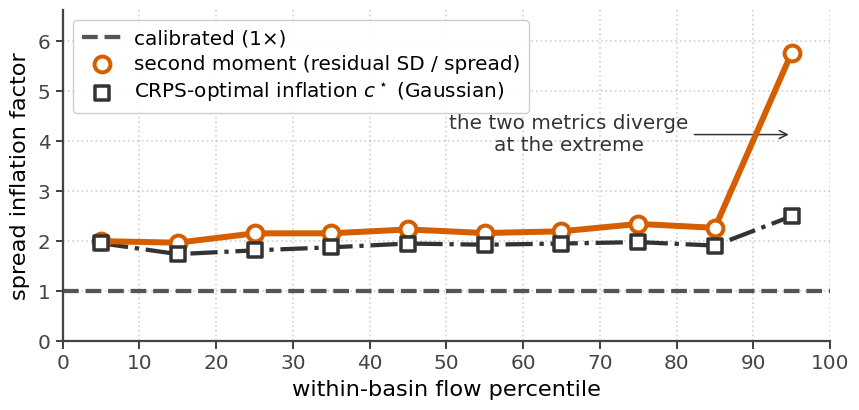

decile   c* (CRPS)   undersize (SD)   CRPS penalty at c=1
  0-10       1.96           2.00                8.8%
 10-20       1.74           1.97                5.9%
 20-30       1.82           2.16                6.4%
 30-40       1.88           2.16                6.9%
 40-50       1.95           2.23                7.5%
 50-60       1.93           2.16                7.1%
 60-70       1.95           2.20                7.0%
 70-80       1.98           2.34                6.8%
 80-90       1.91           2.27                5.8%
 90-100      2.50           5.76                6.1%

plateau (0-90%): c* mean 1.90  vs  SD-based 2.16   -> AGREE (~2x)
top decile:      c*      2.50  vs  SD-based 5.76   -> DIVERGE (2.3x apart)
CRPS penalty for using the raw spread (c=1): 5.8-8.8% across deciles


In [10]:
# RESERVE (exported but not a paper figure): CRPS-optimal spread inflation vs the
# second-moment undersize factor of Figure 1. Shows where the two metrics agree and diverge.
from scipy.stats import norm
SQPI = 1/np.sqrt(np.pi)
def mean_crps(r, s):
    z = r/s
    return np.mean(s*(z*(2*norm.cdf(z)-1) + 2*norm.pdf(z) - SQPI))
def c_star(r, s):
    g = np.exp(np.linspace(np.log(0.4), np.log(14), 60))
    v = np.array([mean_crps(r, c*s) for c in g]); k = int(v.argmin())
    g2 = np.exp(np.linspace(np.log(g[max(k-1,0)]), np.log(g[min(k+1,59)]), 41))
    v2 = np.array([mean_crps(r, c*s) for c in g2]); k2 = int(v2.argmin())
    return g2[k2], v2[k2], mean_crps(r, s)

cc = np.arange(5,100,10); cst = np.empty(10); und = np.empty(10); pen = np.empty(10)
for k in range(10):
    m = (bi==k)&tb; r = (y-mu)[m]; s = np.sqrt(sigma_e2[m])*CORR
    cst[k], vmin, v1 = c_star(r, s)
    und[k] = r.std()/np.sqrt(np.mean(s**2)); pen[k] = 100*(v1/vmin - 1)

fig, ax = plt.subplots(figsize=figsize(2.3))
ax.axhline(1.0, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=2, label="calibrated (1×)")
ax.plot(cc, und, "-", color=PALETTE["ens"], lw=LW["curve"], zorder=4)
ax.scatter(cc, und, s=sz(40), facecolor="white", edgecolor=PALETTE["ens"], linewidths=1.6*S,
           zorder=5, label="second moment (residual SD / spread)")
ax.plot(cc, cst, "-.", color="#333333", lw=LW["ref"], zorder=3)
ax.scatter(cc, cst, s=sz(34), marker="s", facecolor="white", edgecolor="#333333",
           linewidths=1.4*S, zorder=5, label="CRPS-optimal inflation $c^\\star$ (Gaussian)")
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel("spread inflation factor")
ax.set_xlim(0,100); ax.set_ylim(0, max(und.max(), cst.max())*1.15)
ax.set_xticks(range(0,101,10)); ax.set_xticklabels(range(0,101,10))
ax.annotate("the two metrics diverge\nat the extreme", xy=(95, (und[9]+cst[9])/2),
            xytext=(66, (und[9]+cst[9])/2), textcoords="data", ha="center", va="center",
            fontsize=FS["ann"], color="#333333",
            arrowprops=dict(arrowstyle="->", lw=LW["thin"], color="#333333"))
ax.legend(loc="upper left", **LEG).set_zorder(7)
fig.savefig(FIG_OUT/"workshop_crps_check.png"); plt.show()

print("decile   c* (CRPS)   undersize (SD)   CRPS penalty at c=1")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<3d} {cst[k]:9.2f} {und[k]:14.2f} {pen[k]:18.1f}%")
print(f"\nplateau (0-90%): c* mean {cst[:9].mean():.2f}  vs  SD-based {und[:9].mean():.2f}   -> AGREE (~2x)")
print(f"top decile:      c*      {cst[9]:.2f}  vs  SD-based {und[9]:.2f}   -> DIVERGE ({und[9]/cst[9]:.1f}x apart)")
print(f"CRPS penalty for using the raw spread (c=1): {pen.min():.1f}-{pen.max():.1f}% across deciles")

### Is panel (a)'s shift seasonality, or 2021?

Panel (a) shows both event blocks sitting away from uniform — the heat dome loaded toward high flow, the AR block humped mid-range. Neither is evidence about 2021 on its own: those windows are **1 Jun – 31 Jul** and **20 Oct – 10 Dec**, and any basin has a characteristic flow level in those seasons regardless of year. The shape in (a) could be pure seasonality.

The check: hold the calendar window fixed and vary the year. For every test year 2013–2022, take the basin-days in that window (same basins as the block — all 269 for the heat dome, the 74 west of $-121^\circ$ for the AR) and compare their flow-percentile distributions. If 2021 sits inside the spread of the other nine years, seasonality explains panel (a) and 2021 adds nothing. If it separates, the event does.

**Metric.** Jensen–Shannon divergence (base 2, so bounded $[0,1]$ bits) between each year's percentile histogram and the pooled remaining test years, on 20 bins of width 5. Computed **leave-one-year-out for every year**, not just 2021 — a JS value alone is uninterpretable, but 2021's rank among ten years of ordinary interannual variation is not. Percentiles are within-basin over the full test period, so they are already comparable across basins.

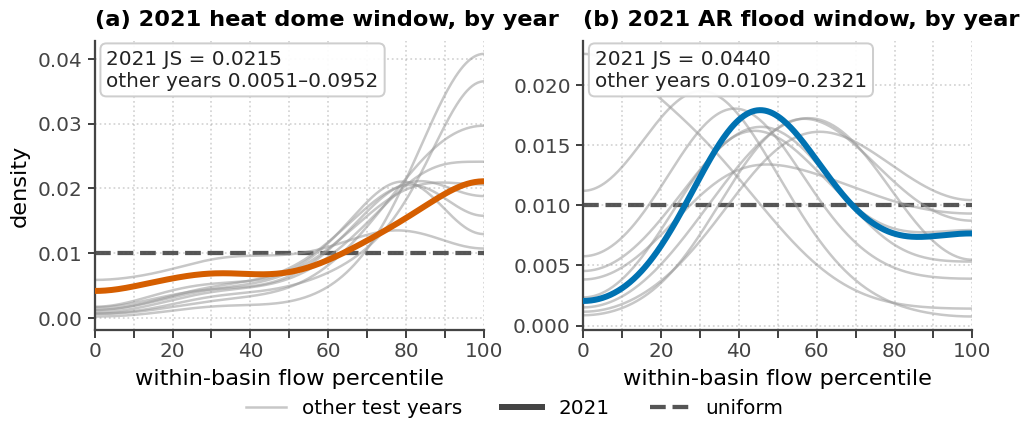


2021 heat dome  — same calendar window, 10 test years
  year  basin-days  median pct   % >90th  JS vs other yrs
  2013      16,368        83.5     31.8%           0.0227
  2014      16,409        79.9     24.8%           0.0087
  2015      16,406        60.3      9.6%           0.0816
  2016      16,403        74.1      8.7%           0.0460
  2017      16,409        76.7     19.8%           0.0051
  2018      16,363        74.7     11.8%           0.0263
  2019      16,398        76.7     16.4%           0.0100
  2020      16,382        89.2     47.1%           0.0952
  2021      16,409        72.6     22.8%           0.0215   <-- event year
  2022      16,389        87.0     43.3%           0.0518
  2021 JS = 0.0215; other years median 0.0263, range 0.0051-0.0952
  -> 2021 ranks 7 of 10 by divergence from the rest (NOT the most divergent year)

2021 AR flood  — same calendar window, 10 test years
  year  basin-days  median pct   % >90th  JS vs other yrs
  2013       3,848        31.

In [11]:
# Seasonality control for Fig 1(a): same calendar window, different years.
from scipy.spatial.distance import jensenshannon
MD = dates.month.to_numpy()*100 + dates.day.to_numpy()
WINDOWS = {"2021 heat dome": dict(md=(MD>=601)&(MD<=731),   basins=np.ones(len(stations),bool),
                                  col=PALETTE["ens"]),
           "2021 AR flood":  dict(md=(MD>=1020)&(MD<=1210), basins=AR_WEST,
                                  col=PALETTE["indist"])}
YEARS = np.arange(2013, 2023)
EDGES = np.linspace(0, 100, 21)                       # 20 bins of width 5
grid  = np.linspace(0, 100, 301)
def hist(v):
    h,_ = np.histogram(v, bins=EDGES); return h/max(h.sum(),1)
def kde_refl(v, sub=20_000, seed=0):
    s = v if len(v)<=sub else np.random.default_rng(seed).choice(v, sub, replace=False)
    return 3*gaussian_kde(np.concatenate([s, -s, 200-s]))(grid)

fig, axs = plt.subplots(1, 2, figsize=figsize(2.3), layout="constrained")
report = {}
for ax,(nm,cfg) in zip(axs, WINDOWS.items()):
    per_year = {}
    for yr in YEARS:
        m = ((test & cfg["md"] & (dates.year==yr))[:,None] & valid) & cfg["basins"][None,:]
        v = pct[m]*100; v = v[np.isfinite(v)]
        if len(v) >= 200: per_year[yr] = v
    for yr,v in per_year.items():
        if yr == 2021: continue
        ax.plot(grid, kde_refl(v), "-", color="#999999", lw=1.0*S, alpha=.55, zorder=2)
    ax.plot(grid, kde_refl(per_year[2021]), "-", color=cfg["col"], lw=LW["curve"], zorder=4)
    ax.axhline(0.01, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=1)
    # leave-one-year-out JS: every year against the pooled others, so 2021 has a null to sit in
    js = {}
    for yr,v in per_year.items():
        other = np.concatenate([w for y2,w in per_year.items() if y2 != yr])
        js[yr] = float(jensenshannon(hist(v), hist(other), base=2)**2)
    report[nm] = (per_year, js)
    oth = np.array([j for yr,j in js.items() if yr != 2021])
    ax.set_xlim(0,100); ax.set_xticks(_XT); ax.set_xticklabels(_XL)
    ax.set_xlabel("within-basin flow percentile")
    ax.set_title(f"({'ab'[list(WINDOWS).index(nm)]}) {nm} window, by year",
                 loc="left", fontsize=FS["sub"], fontweight="bold")
    ax.annotate(f"2021 JS = {js[2021]:.4f}\nother years {oth.min():.4f}–{oth.max():.4f}",
                xy=(.03,.97), xycoords="axes fraction", va="top", ha="left",
                fontsize=FS["ann"], color="#222222",
                bbox=dict(boxstyle="round,pad=.3", fc="white", ec="#CCCCCC", lw=.8*S, alpha=.95))
axs[0].set_ylabel("density")
fig.legend(handles=[Line2D([],[], color="#999999", lw=1.0*S, alpha=.55, label="other test years"),
                    Line2D([],[], color="#444444", lw=LW["curve"], label="2021"),
                    Line2D([],[], color=PALETTE["ref"], ls="--", lw=LW["ref"], label="uniform")],
           loc="outside lower center", ncol=3, frameon=False, fontsize=FS["leg"])
fig.savefig(FIG_OUT/"workshop_seasonality_check.png"); plt.show()

for nm,(per_year,js) in report.items():
    print(f"\n{nm}  — same calendar window, {len(per_year)} test years")
    print(f"{'year':>6s} {'basin-days':>11s} {'median pct':>11s} {'% >90th':>9s} {'JS vs other yrs':>16s}")
    for yr in sorted(per_year):
        v = per_year[yr]
        print(f"{yr:6d} {len(v):11,d} {np.median(v):11.1f} {100*np.mean(v>90):8.1f}% {js[yr]:16.4f}"
              + ("   <-- event year" if yr==2021 else ""))
    oth = np.array([j for yr,j in js.items() if yr != 2021])
    rank = int((oth >= js[2021]).sum()) + 1
    print(f"  2021 JS = {js[2021]:.4f}; other years median {np.median(oth):.4f}, range {oth.min():.4f}-{oth.max():.4f}")
    print(f"  -> 2021 ranks {rank} of {len(js)} by divergence from the rest "
          + ("(most divergent)" if rank==1 else "(NOT the most divergent year)"))